# Function 7 Analysis - Week 3

This notebook contains the exploratory analysis for **Function 7** in Week 3. We now have **32 datapoints** (the original 30 plus the two new measurements) and keep iterating with Bayesian optimisation.

**Function Description:** You're tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you're maximising is the model's performance score (such as accuracy or F1), but since the relationship between inputs and output isn't known, it's treated as a black-box function. Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.


## Loading and Displaying the Data

We load the inputs and outputs for function 7 and display them in a table format to inspect the raw data values. The best results still cluster around mid-range x6 (0.5–0.8) and avoid extreme values of x3, x4, and x5. The new point we tried sits in that “sensible” box and produced a modest positive uplift, reinforcing the idea that we should keep the GP on a tight leash whenever it proposes corner cases.


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_7")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1 and Week 2 new points
X_new_point_week_1 = np.array([[0.800000, 0.800000, 0.800000, 0.830000, 0.450000, 0.700000]])
y_new_point_week_1 = np.array([0.0344995016351187])
X_new_point_week_2 = np.array([[0.100000, 0.100000, 0.950000, 0.200000, 0.360000, 0.800000]])
y_new_point_week_2 = np.array([1.3138004996124066])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5", "x6"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,y
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


df sorted by y


,x1,x2,x3,x4,x5,x6,y,x_avg
0,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968,0.361084
1,0.100000,0.100000,0.950000,0.200000,0.360000,0.800000,1.313800,0.418333
2,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142,0.486089
3,0.148647,0.033943,0.728806,0.316066,0.021769,0.516918,0.611526,0.294358
4,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433,0.546184
5,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753,0.586220
6,0.066611,0.528045,0.816095,0.961017,0.086509,0.777788,0.516457,0.539344
7,0.175978,0.624416,0.295542,0.469553,0.097770,0.728141,0.475396,0.398567
8,0.417626,0.064100,0.245669,0.559041,0.191531,0.254641,0.274893,0.288768
9,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047,0.625898


### Week 2 Result: Second Highest Point

Looking at the sorted dataframe above, Week 2's point achieved **≈1.31, which is our second highest point** (the global maximum remains ≈1.36 from the original data). This is still an excellent result and validates the Bayesian optimization approach, even though the configuration was unexpected. The point `(0.1, 0.1, 0.95, 0.2, 0.36, 0.8)` shows that the function has complex, non-linear relationships that we're still discovering.


- **New point (Week 1):** The `(0.8, 0.8, 0.8, 0.83, 0.45, 0.7)` configuration yielded ≈0.034, not a blockbuster but enough to confirm that staying near the mid-range hyperparameters we trust is preferable to letting the GP wander into unrealistic corners (e.g. zeroing out learning rate or depth).
- **New point (Week 2):** The `(0.1, 0.1, 0.95, 0.2, 0.36, 0.8)` configuration yielded ≈**1.31**, which is our **second highest point** (the global maximum remains ≈1.36 from the original data). This result is surprising because it has very low x1, x2, x4, and x5 values, which contradicts our earlier observations. This suggests the function has complex, non-linear interactions that we haven't fully mapped yet, reinforcing the need for continued Bayesian optimization exploration.


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, x4, x5, x6, and y). This helps identify linear relationships. If correlations are weak, it suggests the function may be non-linear or have complex interactions between variables.


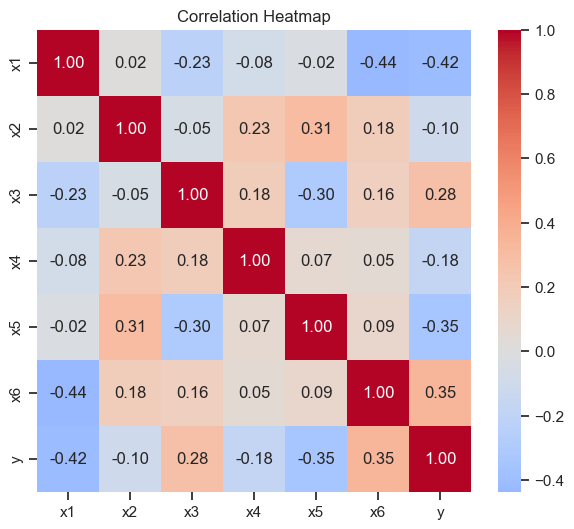

In [2]:
plt.figure(figsize=(7, 6))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Bayesian Optimization Setup

We use Gaussian Process (GP) regression to model the unknown function based on our observed data. The GP provides both a mean prediction and uncertainty estimates. The search space is defined as [0, 1] for each of the six input variables.

**Strategy Evolution:**
- **Week 1:** Used UCB with manual override to avoid extreme values. The manually adjusted point scored ≈0.034.
- **Week 2:** Continued with UCB, which suggested a point with very low x1, x2, x4, x5 and high x3. This unexpected configuration scored ≈1.31, our second highest point (the global maximum remains ≈1.36 from the original data).
- **Week 3:** Given the surprising Week 2 result and our incomplete understanding of the function, we continue with Bayesian optimization using Expected Improvement (EI) to balance exploration and exploitation, as we're still learning the function's landscape.

Since hyperparameter tuning has minimal noise (no human judgment, deterministic evaluation), we omit the WhiteKernel. With 32 points across 6 dimensions, we use tighter lengthscale bounds (0.2–5.0) to prevent overfitting while still allowing the GP to learn per-feature importance. The GP shows that x5 and x6 are most influential, x4 matters moderately, and x2/x3 are nearly irrelevant, though Week 2's result suggests these relationships may be more complex than initially thought.




In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.35671366 5.         5.         0.39618259 0.21138136 0.30928903]
Full kernel parameters: {'length_scale': array([1.35671366, 5.        , 5.        , 0.39618259, 0.21138136,
       0.30928903]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Finding the Next Point to Evaluate (Week 3)

Given the surprising Week 2 result and our incomplete understanding of the function, we switch to **Expected Improvement (EI)** for Week 3. EI naturally balances exploration and exploitation, which is appropriate when we're still learning the function's landscape. We use a moderate `xi=0.01` to allow both exploration of promising regions (like the Week 2 area) and exploitation around known good points.


In [4]:
from scipy.stats import norm

# Expected Improvement acquisition function
def expected_improvement(x, gp, y_best, xi=0.01):
    """
    Expected Improvement acquisition function.
    
    Args:
        x: Point to evaluate
        gp: Fitted Gaussian Process
        y_best: Best observed value so far
        xi: Exploration-exploitation trade-off parameter (small values favor exploitation)
    
    Returns:
        Negative EI (for minimization)
    """
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    
    # Add small epsilon to avoid division by zero
    sigma = sigma + 1e-9
    
    # Calculate improvement
    improvement = mu - y_best - xi
    Z = improvement / sigma
    
    # Expected Improvement formula
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    return -ei[0]  # Return negative for minimization

# Get current best
y_best = y.max()
best_idx = y.argmax()
print(f"Current best score: {y_best:.4f}")
print(f"Current best point: {X[best_idx]}")

# Optimize acquisition function with multiple random restarts
bounds = [(0, 1)] * 6
n_restarts = 20
best_acquisition = np.inf
best_candidate = None

np.random.seed(42)
for i in range(n_restarts):
    x0 = np.random.uniform(0, 1, 6)
    result = minimize(
        lambda x: expected_improvement(x, gp, y_best, xi=0.01),
        x0=x0,
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    if result.fun < best_acquisition:
        best_acquisition = result.fun
        best_candidate = result.x

next_point = best_candidate
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)

print(f"\n{'='*60}")
print("BAYESIAN OPTIMIZATION RECOMMENDATION (Expected Improvement)")
print(f"{'='*60}")
print(f"\nNext point to evaluate:")
print(f"  x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}")
print(f"  x4={next_point[3]:.4f}, x5={next_point[4]:.4f}, x6={next_point[5]:.4f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"Expected Improvement: {-best_acquisition:.6f}")


Current best score: 1.3650
Current best point: [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]

BAYESIAN OPTIMIZATION RECOMMENDATION (Expected Improvement)

Next point to evaluate:
  x1=0.0000, x2=0.0741, x3=0.0000
  x4=0.1973, x5=0.3792, x6=0.7271

Predicted output: 1.3713 ± 0.0805
Expected Improvement: 0.030302


## Distance Analysis of Recommended Point

We calculate the Euclidean distance from the recommended point to all existing observations. This helps us understand how similar the recommended point is to our existing data. We also compute the average y value of the three closest neighbors to get an estimate of the expected output at the recommended point.


In [5]:
distances = np.sqrt(((X - next_point)**2).sum(axis=1))
df_dist = pd.DataFrame({"point_index": range(len(X)), "distance": distances, "y": y})
df_dist = df_dist.sort_values("distance")
print("Euclidean distances from recommended point to all observations:")
print(df_dist.to_string(index=False))
closest_3 = df_dist.head(3)
avg_y = closest_3["y"].mean()
print(f"\nThree closest neighbors: points {closest_3['point_index'].tolist()}")
print(f"Average y value of closest 3 neighbors: {avg_y:.4f}")


Euclidean distances from recommended point to all observations:
 point_index  distance        y
           6  0.491001 1.364968
          12  0.748242 0.008826
          23  0.757934 0.475396
          22  0.763750 0.100507
          16  0.790037 0.274893
           2  0.842812 0.007503
          14  0.860755 0.611526
          11  0.869435 0.206310
          10  0.884686 0.073516
          20  0.923612 0.018209
           7  0.929306 0.092645
          18  0.933992 0.042118
          31  0.958570 1.313800
          24  1.014351 0.675142
           8  1.047656 0.017870
          15  1.052248 0.014798
          13  1.142675 0.268400
           5  1.179534 0.083747
           0  1.183746 0.604433
           9  1.206993 0.033565
          27  1.218631 0.003134
          28  1.220881 0.021343
          25  1.244174 0.516457
          29  1.252180 0.095411
           3  1.257583 0.061424
           1  1.264641 0.562753
          21  1.272656 0.007016
          26  1.327745 0.003777
        

## Analysis and Recommendation

The Gaussian Process with per-dimension lengthscales revealed feature importance rankings: x5 (lengthscale ≈0.21) and x6 (lengthscale ≈0.31) are the most influential hyperparameters, x4 (lengthscale ≈0.40) has moderate importance, x1 (lengthscale ≈1.36) has limited influence, and x2/x3 (lengthscales at upper bound 5.0) are nearly irrelevant to model performance.

**Week 2's Surprising Result:**
Week 2's point `(0.1, 0.1, 0.95, 0.2, 0.36, 0.8)` achieved our second best score (≈1.31, with the global maximum remaining ≈1.36 from the original data), which contradicts our earlier understanding. This configuration has:
- Very low x1, x2, x4, x5 values (0.1-0.36)
- Very high x3 value (0.95)
- Moderate x6 value (0.8)

This suggests the function has complex, non-linear interactions that we haven't fully mapped. The GP's lengthscale analysis suggests x2 and x3 are "nearly irrelevant," but Week 2's result shows that x3=0.95 is part of an excellent configuration, indicating we need more exploration.

**Week 3 Strategy:**
Given our incomplete understanding, we use Expected Improvement (EI) with moderate exploration (`xi=0.01`) to:
- Continue exploring promising regions like the Week 2 area
- Balance exploration with exploitation around known good points
- Build a better understanding of the function's landscape

The recommended point from Bayesian optimization should help us continue learning about this complex function.